<a href="https://colab.research.google.com/github/Amna-Sarfaraz/Python/blob/studentperformance/House_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import matplotlib.pyplot as plt

In [86]:

df = pd.read_csv('/content/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [87]:
# Create a NumPy array from the "median income" column.
np_array=np.array(df["median_income"])
print(np_array)

[8.3252 8.3014 7.2574 ... 1.7    1.8672 2.3886]


In [88]:

# Normalize this array using NumPy operations.
arr_min=np_array.min()
arr_max=np_array.max()
normalized=(np_array-arr_min)/(arr_max-arr_min)
print(normalized)

[0.53966842 0.53802706 0.46602805 ... 0.08276438 0.09429525 0.13025338]


In [89]:
# Calculate the mean, median, standard deviation, and IQR using NumPy.
mean=np.mean(np_array)
median=np.median(np_array)
std=np.std(np_array)
q1=np.percentile(np_array,25)
q3=np.percentile(np_array,75)
iqr=q3-q1
print(mean,median,std,iqr)

# Create a new NumPy array that labels income levels as:
# Low (<2)
# Medium (2–4)
# High (>4)

low_income=np_array[np_array<2]
medium_income=np_array[(np_array>2)&(np_array<4)]
high_income=np_array[np_array>4]
print(low_income,medium_income,high_income)

# Load the dataset into a Pandas DataFrame.
pd_df=pd.DataFrame(df)


# Perform basic EDA:
# Head, info, shape, describe
# display(pd_df.head())
# display(pd_df.info())
# display(pd_df.shape)
# display(pd_df.describe())

# Check and handle missing values.
# display(pd_df.isnull().sum())

mean_value=pd_df['total_bedrooms'].mean()
pd_df['total_bedrooms'] = pd_df['total_bedrooms'].fillna(mean_value)

# display(pd_df.isnull().sum())

# Create new columns:
# Population per household
# Rooms per person how??
pd_df['population_per_household']=pd_df['population']/pd_df['households']
pd_df['rooms_per_person']=pd_df['total_rooms']/pd_df['population']
# display(pd_df.head())


3.8706710029069766 3.5347999999999997 1.8997756945748738 2.17985
[1.9167 1.9911 1.3578 ... 1.5603 1.7    1.8672] [3.8462 3.6591 3.12   ... 3.7125 2.5568 2.3886] [8.3252 8.3014 7.2574 ... 5.679  4.5625 4.125 ]


In [90]:

# Sort the data by median house value (descending).
# display(pd_df.sort_values(by='median_house_value',ascending=False))

# Group your dataset by the ocean_proximity column and compute:
# Mean median income
# Average house value
# Total population
grouped=df.groupby('ocean_proximity')
summary=grouped.agg({'median_income':'mean','median_house_value':'mean','population':'sum'})
print(summary)


# Select relevant features (X) and target variable (y).
y=pd_df['median_house_value']
X=pd_df.drop('median_house_value',axis=1)

# Handle categorical features
X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)


# Split the data into train-test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)

model.fit(X_train,y_train)
y_pred=model.predict(X_test)

print("RandomForestRegressor:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))





                 median_income  median_house_value  population
ocean_proximity                                               
<1H OCEAN             4.230682       240084.285464  13889374.0
INLAND                3.208996       124805.392001   9112744.0
ISLAND                2.744420       380440.000000      3340.0
NEAR BAY              4.172885       259212.311790   2817427.0
NEAR OCEAN            4.005785       249433.977427   3598955.0
RandomForestRegressor:
MAE: 33339.99346214117
MSE: 2476572269.400198
R2 Score: 0.8110076845837273


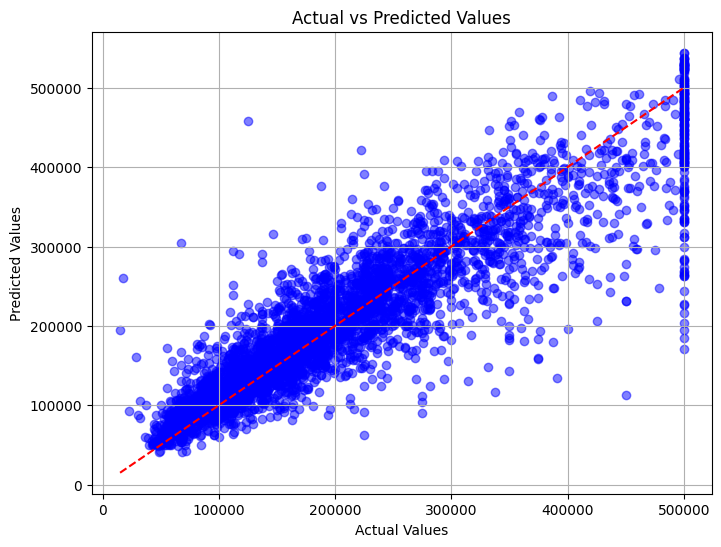

In [91]:
# Plot actual vs predicted values (scatter plot).
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred,alpha=0.5,color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.grid(True)
plt.show()